### ***TP FIREWALL***

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tunguz/internet-firewall-data-set")

print("Path to dataset files:", path)

100%|██████████| 754k/754k [00:00<00:00, 70.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/tunguz/internet-firewall-data-set/versions/1


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [10]:
df = pd.read_csv(os.path.join(path, "log2.csv"))
df.head()

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18


## QUESTION 1 : Comptage des Actions

Comptez combien de fois chaque action (`allow`, `deny`, etc.) apparaît dans le fichier.

-->

In [13]:
#Pour compter combien de fois chaque action apparait
df["Action"].value_counts()

,count
Action,
allow,37640
deny,14987
drop,12851
reset-both,54


D'après ces chiffres, la politique du pare-feu vous semble-t-elle plutôt permissive (beaucoup d'autorisations) ou restrictive ?

--> A mon avis, elle semble plutôt permissive car il y'a quand même un grand nombre d'action

### QUESTION 2 : Les Ports les plus sollicités
Affichez les 10 ports de destination les plus fréquents dans le dataset:

-->


In [15]:
df["Destination Port"].value_counts().head(10)

,count
Destination Port,
53,15414
445,12891
443,11684
80,4035
25174,1087
5900,909
37965,826
22114,767
64147,756


Identifiez un numéro de port standard dans ce Top 10 et expliquez brièvement à quoi il sert (ex: 80, 443, 53...).

--> J'ai choisi le numéro 443 car c'est le port de HTTPS, utilisé pour le trafic web sécurisé


### QUESTION 3 : Analyse des Rejets
Créez un nouveau tableau appelé `rejets` contenant uniquement les lignes de type `deny`, puis trouvez quel est le port le plus rejeté.

-->


In [18]:
#On crée un tableau contenant les action deny qu'on appelera rejets
rejets = df[df["Action"] == "deny"]

In [20]:
#Nous donne le port le plus rejeté
rejets["Destination Port"].value_counts().head(1)

,count
Destination Port,
25174,1087


Pourquoi, selon vous, les attaquants s'intéressent-ils autant à ce port en particulier ?

--> Les attaquants l’utilisent probablement pour scanner des ports aléatoires ou tester des services non documentés.

### QUESTION 4 : Analyse de Volume (Paquets)
Calculez la moyenne du nombre de paquets (`Packets`) envoyés pour chaque type d'Action.

-->

In [23]:
#Pour calculer la moyenne du nombre de paquets pour chaque type d’action
df.groupby("Action")["Packets"].mean()


,Packets
Action,
allow,178.348565
deny,1.003270
drop,1.000000
reset-both,1.666667


Pourquoi le nombre de paquets est-il très faible (proche de 1) pour les actions `deny` par rapport aux flux `allow` ?

--> Le nombre de paquets est très faible pour les actions deny car la connexion est bloquée dès le premier paquet. À l’inverse, les flux allow laissent passer toute la communication, ce qui génère beaucoup plus de paquets.

### QUESTION 5 : Répartition Visuelle
Affichez un graphique (`countplot`) pour visualiser la répartition des différentes Actions.

-->

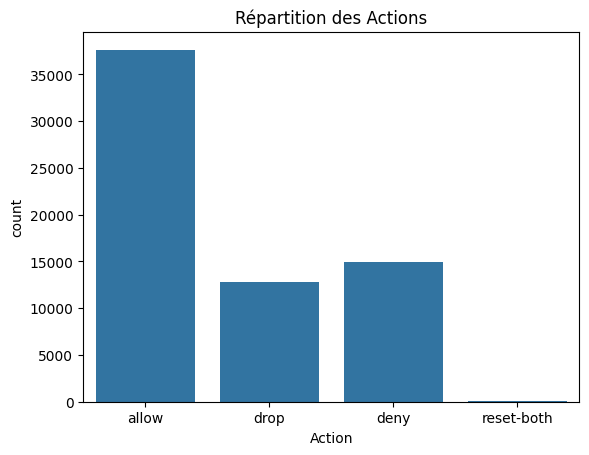

In [25]:
sns.countplot(data=df, x="Action")
plt.title("Répartition des Actions")
plt.show()

ANALYSE Q5 :Que montre visuellement ce graphique sur l'état du réseau ce jour-là ?

--> Le graphique montre que la majorité du trafic réseau a été autorisée (allow), tandis qu’une proportion beaucoup plus faible de paquets a été rejetée (deny) ou ignorée (drop). Cela indique que le réseau fonctionnait normalement ce jour‑là : la plupart des communications étaient légitimes et acceptées, et seules quelques tentatives suspectes ou non conformes ont été bloquées par le firewall.

### QUESTION 6 : Chasse aux Anomalies (Volume)
Affichez un graphique de points (`scatterplot`) pour voir la relation entre `Packets` et `Bytes Sent`.

-->

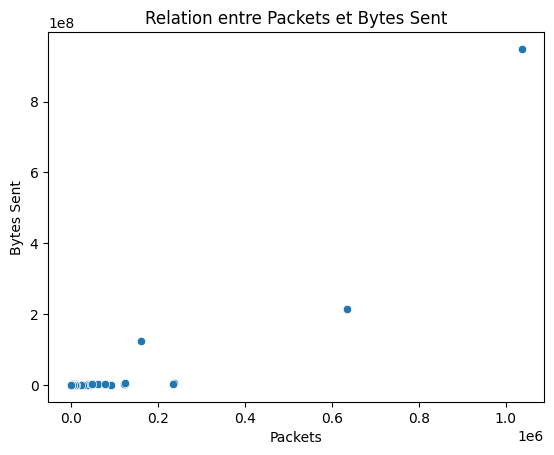

In [26]:
sns.scatterplot(data=df, x="Packets", y="Bytes Sent")
plt.title("Relation entre Packets et Bytes Sent")
plt.show()

**ANALYSE Q6 :** Voyez-vous des points extrêmement isolés tout en haut ? En quoi est-ce une alerte de sécurité (exfiltration de données) ?

--> Oui, on observe des points très isolés en haut du graphique : ce sont des flux qui envoient une quantité anormalement élevée de données (Bytes Sent) avec un nombre de paquets relativement faible. Ce comportement est typique d’une tentative d’exfiltration de données, où un attaquant cherche à transférer un gros volume d’informations en un minimum de paquets pour rester discret.

### QUESTION 7 : Temps de Session Moyenne
Calculez le temps moyen de connexion (`Elapsed Time (sec)`) pour chaque type d'Action.

-->

In [28]:
df.groupby("Action")["Elapsed Time (sec)"].mean()

,Elapsed Time (sec)
Action,
allow,114.617349
deny,0.000133
drop,0.000000
reset-both,0.129630


Pourquoi les flux rejetés ont-ils un temps moyen de 0 seconde ?

--> Car la connexion est bloquée immédiatement par le firewall.

**BILAN FINAL :**
En tant qu'analyste, quelle serait votre première recommandation technique suite à ces découvertes ?

--> Je renforcerais la surveillance des ports non standards et des flux sortants, parce que c’est clairement là que j’ai vu le plus d’activité suspecte.
L’idée, c’est de réduire la surface d’attaque et d’éviter qu’un scan ou une exfiltration passe inaperçu.